# Ejercicio 01  MLP manual: Iris

Esta es una copia de trabajo. Los notebooks originales no se modifican. Ejecutaremos primero la topologia `4 x 3 x 3` y despues `4 x 3 x 3 x 3 x 3`, manteniendo sigmoide, MSE, `eta=0.03` y 500 epocas.

## Paso 1  Preparacion

Fijamos semillas para que la comparacion sea reproducible. La funcion `forward` trabaja con cualquier numero de capas y `backward_update` recorre las capas desde la salida hacia la entrada.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

SEED = 123
ETA = 0.03
EPOCHS = 500
np.random.seed(SEED)

iris = datasets.load_iris()
X = iris.data.astype(float)
y = iris.target
Y = to_categorical(y).astype(float)
print("X:", X.shape, "Y:", Y.shape)


X: (150, 4) Y: (150, 3)


## Paso 2  Implementacion general

Cada matriz de pesos tiene forma `(neuronas_de_salida, neuronas_de_entrada + 1)`. La primera columna es el sesgo. Asi, agregar capas no exige duplicar codigo: solo cambia la lista de tamaos.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))

def init_weights(sizes, seed):
    rng = np.random.default_rng(seed)
    return [rng.uniform(-0.5, 0.5, size=(sizes[i + 1], sizes[i] + 1))
            for i in range(len(sizes) - 1)]

def forward(x, weights):
    activations = [np.asarray(x, dtype=float)]
    for W in weights:
        previous = np.concatenate(([1.0], activations[-1]))
        activations.append(sigmoid(W @ previous))
    return activations

def mse(weights):
    total = 0.0
    for x_i, y_i in zip(X, Y):
        prediction = forward(x_i, weights)[-1]
        total += np.sum((y_i - prediction) ** 2)
    return total / len(X)

def backward_update(x_i, y_i, weights, eta):
    activations = forward(x_i, weights)
    deltas = [None] * len(weights)
    output = activations[-1]
    deltas[-1] = output * (1.0 - output) * (y_i - output)
    for layer in range(len(weights) - 2, -1, -1):
        next_weights = weights[layer + 1][:, 1:]
        next_delta = deltas[layer + 1]
        current = activations[layer + 1]
        deltas[layer] = current * (1.0 - current) * (next_weights.T @ next_delta)
    for layer, W in enumerate(weights):
        previous = np.concatenate(([1.0], activations[layer]))
        W += eta * np.outer(deltas[layer], previous)

def train(sizes, seed):
    weights = init_weights(sizes, seed)
    errors = [mse(weights)]
    started = time.perf_counter()
    for epoch in range(EPOCHS):
        for x_i, y_i in zip(X, Y):
            backward_update(x_i, y_i, weights, ETA)
        errors.append(mse(weights))
    elapsed = time.perf_counter() - started
    predictions = np.array([forward(x_i, weights)[-1] for x_i in X])
    classes = predictions.argmax(axis=1)
    accuracy = np.mean(classes == y)
    return weights, np.array(errors), elapsed, accuracy


## Paso 3  Corrida original `4 x 3 x 3`

Esta es la referencia. No se cambia la funcion de activacion, la perdida, la tasa ni las epocas.

Topologia: 4 x 3 x 3 | error inicial: 0.695555 | error final: 0.059584 | accuracy: 0.9667 | tiempo: 6.028 s


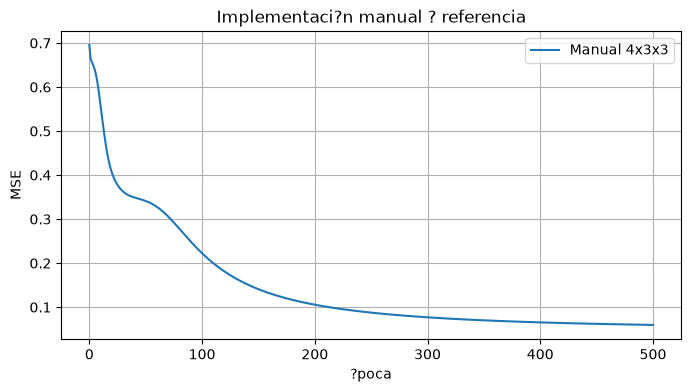

In [3]:
manual_original = train([4, 3, 3], seed=SEED)
weights_original, errors_original, time_original, acc_original = manual_original
print(f"Topologia: 4 x 3 x 3 | error inicial: {errors_original[0]:.6f} | error final: {errors_original[-1]:.6f} | accuracy: {acc_original:.4f} | tiempo: {time_original:.3f} s")
plt.figure(figsize=(8, 4))
plt.plot(errors_original, label="Manual 4x3x3")
plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Implementacion manual  referencia"); plt.legend(); plt.grid(True); plt.show()


## Paso 4  Corrida profunda `4 x 3 x 3 x 3 x 3`

Se agregan exactamente dos capas ocultas de tres neuronas. La salida continua teniendo tres neuronas.

Topologia: 4 x 3 x 3 x 3 x 3 | error inicial: 0.681967 | error final: 0.670880 | accuracy: 0.3333 | tiempo: 11.927 s


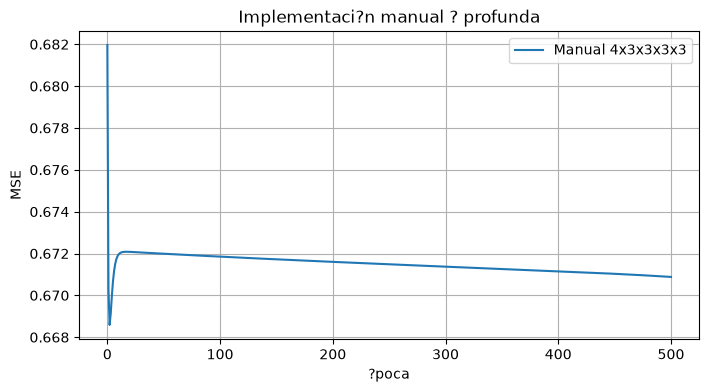

In [4]:
manual_deep = train([4, 3, 3, 3, 3], seed=SEED)
weights_deep, errors_deep, time_deep, acc_deep = manual_deep
print(f"Topologia: 4 x 3 x 3 x 3 x 3 | error inicial: {errors_deep[0]:.6f} | error final: {errors_deep[-1]:.6f} | accuracy: {acc_deep:.4f} | tiempo: {time_deep:.3f} s")
plt.figure(figsize=(8, 4))
plt.plot(errors_deep, label="Manual 4x3x3x3x3")
plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Implementacion manual  profunda"); plt.legend(); plt.grid(True); plt.show()


## Paso 5  Comparacion manual

La grafica conjunta y la tabla permiten comparar las dos corridas con la misma metrica.

{'manual_original_final_error': 0.05958393835944052, 'manual_deep_final_error': 0.6708796681284948, 'manual_original_accuracy': 0.9666666666666667, 'manual_deep_accuracy': 0.3333333333333333, 'manual_original_time': 6.028262000007089, 'manual_deep_time': 11.927432299999055}


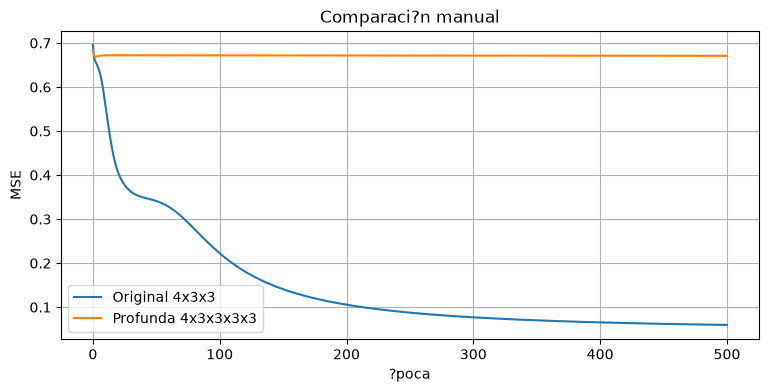

In [5]:
manual_results = {
    "manual_original_final_error": float(errors_original[-1]),
    "manual_deep_final_error": float(errors_deep[-1]),
    "manual_original_accuracy": float(acc_original),
    "manual_deep_accuracy": float(acc_deep),
    "manual_original_time": float(time_original),
    "manual_deep_time": float(time_deep),
}
print(manual_results)
plt.figure(figsize=(9, 4))
plt.plot(errors_original, label="Original 4x3x3")
plt.plot(errors_deep, label="Profunda 4x3x3x3x3")
plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Comparacion manual"); plt.legend(); plt.grid(True); plt.show()


## Reto opcional  aplanamiento cada 50 epocas

La siguiente salida ayuda a observar cundo la curva deja de mejorar. Se mantiene la misma configuracion.

In [6]:
for name, errors in [("manual original", errors_original), ("manual profunda", errors_deep)]:
    print(name)
    for epoch in range(0, len(errors), 50):
        print(f"epoca {epoch:3d}: {errors[epoch]:.6f}")


manual original
epoca   0: 0.695555
epoca  50: 0.341088
epoca 100: 0.222449
epoca 150: 0.140767
epoca 200: 0.105579
epoca 250: 0.087520
epoca 300: 0.076892
epoca 350: 0.070050
epoca 400: 0.065371
epoca 450: 0.062035
epoca 500: 0.059584
manual profunda
epoca   0: 0.681967
epoca  50: 0.671989
epoca 100: 0.671850
epoca 150: 0.671722
epoca 200: 0.671600
epoca 250: 0.671484
epoca 300: 0.671372
epoca 350: 0.671261
epoca 400: 0.671150
epoca 450: 0.671030
epoca 500: 0.670880


## Que guardar como evidencia

Captura las cuatro graficas finales y la tabla de resultados. El reporte se genera a partir de los numeros impresos por estas celdas.
